In [47]:
import numpy as np
import obspy
import os

import functools
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.axes import Axes

from insight.util import TraceFile, trace_slice

In [48]:
def trace_plot(axes: Axes, trace: obspy.Trace, start=10, end=40, t_offset=10, y_offset=0, plt_args={}):
    sliced = trace_slice(start, end, trace)
    times = sliced.times(type="relative")
    times -= t_offset
    data = sliced.data + y_offset
    axes.plot(times, data, **plt_args)

DATA_DIR = "../data/"
datafile = functools.partial(os.path.join, DATA_DIR)
CAT_FILE = "a_quality.parquet"
EVENT = "S1222a"
network, station, location = "XB", "ELYSE", "02"

# img_zrt = np.asarray(Image.open("../img/S1222a_ZRT_0.25-2.0.png"))
# img_prf = np.asarray(Image.open("../img/S1222a_PRF_0.25-1.0_g2.png"))
bandpass = {"freqmin": 0.25, "freqmax": 2.0, "corners": 4, "zerophase": True}

event = pd.read_parquet(datafile(CAT_FILE)).loc[EVENT]
trace_file = TraceFile(network, station, location, event.id)
st_uvw = obspy.read(os.path.join(DATA_DIR, "traces", str(trace_file)))
st_zne = obspy.read(os.path.join(DATA_DIR, "zne", str(trace_file)))
st_zne.rotate(method="NE->RT", back_azimuth=event.mqs_azimuth).detrend().filter(type="bandpass", **bandpass)
event

id                                   mqs2022isne
region name                     Aeolis Northeast
time                 2022-05-04T23:23:07.710516Z
quality                                        A
mqs_azimuth                                109.0
mqs_distance                           37.014014
M_w                                          4.6
arrival         2022-05-04 23:27:45.690496+00:00
phase                                          P
Name: S1222a, dtype: object

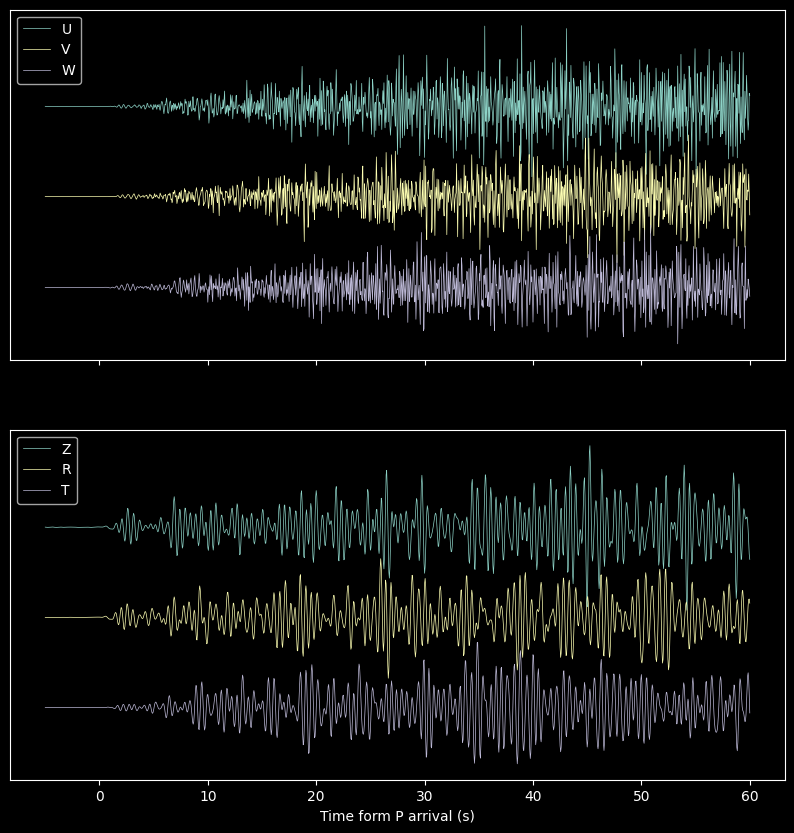

In [53]:
plt.style.use('dark_background')
fig1, axs1 = plt.subplots(2, 1, figsize=(10, 10), dpi=100, sharex=True)
axs1[0].set_yticks([])
axs1[1].set_yticks([])
for i, comp in enumerate("UVW"):
    tr = st_uvw.select(component=comp).traces[0].normalize()
    trace_plot(axs1[0], tr, start=25, end=90, y_offset=.5 - .5 * i, t_offset=5, plt_args={"label": comp, "linewidth": .5})
axs1[0].legend(loc="upper left")

for i, comp in enumerate("ZRT"):
    tr = st_zne.select(component=comp).traces[0].normalize()
    trace_plot(axs1[1], tr, start=25, end=90, y_offset=.5 - .5 * i, t_offset=5, plt_args={"label": comp, "linewidth": .5})
axs1[1].legend(loc="upper left")    
axs1[1].set_xlabel("Time form P arrival (s)")
fig1.savefig(datafile(f"figures/filtering.png"))